# Digital Humanities e Data Management / Informatica per i Beni Culturali (2025/2026)

# **L'arte religiosa, mitologica e ritratti nel Rinascimento: approfondimento sui soggetti femminili**

## 1. Introduzione

Questo progetto analizza un dataframe storico-artistico contentente una serie di quadri italiani. Dopo un'attenta analisi del dataframe mi sono focalizzata in particolare sul movimento del Rinascimento e sulle figure femminili che venivano rappresentate in alcuni generi artisici precisi.

### 1.1. Obiettivi

*   Nel Rinascimento, qual è stata l'evoluzione dei quadri religiosi, mitologici o dei ritratti?
*   Di tutti i quadri che raffigurano donne nel Rinascimento, quanti sono di questi generi?
*   E, nel corso dei secoli, come sono cambiate queste quantità?

### 1.2. Dati utilizzati
Ho utilizzato il dataset storico-artistico estratto da WikiData. I dati sono stati recuperati dal repository di [GitHub di sbrzt](https://github.com/dhdmch/2025-2026/tree/main/data/vapod), sono costituiti da un file csv, formato da 12 colonne e 2444 righe.

Un esempio dei dati utilizzati è il seguente:

| Variabile | Tipo |	Definizione | Esempio |
| :------- | :--- | :--------- | :------ |
|     id | object | ID del quadro su WikiData | http://www.wikidata.org/entity/Q428274 |
|titolo |object  |titolo dell'opera |Ritratto di Fedra Inghirami, detto Fedra|
|artisti|object|nome e genere degli artisti dell'opera|Raffaello Sanzio (maschio)|
|data_creazione|object|intervallo degni anni di creazione dell'opera|1510|
|generi|object|genere artistico dell'opera|ritratto|
|luoghi|object|luogo di conservazione attuale|Galleria Palatina|
|collezioni|object|collezioni di cui l'opera fa parte|Galleria Palatina|
|contenuti|object|contenuti rappresentati nell'opera|libro; carta; scrittura; strabismo; posizione ...|
|movimenti|object|movimento artistico di cui l'opera fa parte|Alto Rinascimento|
|soggetti|object|soggetto principale rappresentato nell'opera|Tommaso Inghirami|
|altezza|float64|altezza dell'opera, in centimetri|91.0|
|larghezza|float64|larghezza dell'opera, in centimetri|61.0|

Il dataset è disponibile su [GitHub](https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csv).

### 1.3. Organizzazione

I dati sono lavorati su Google Colab in questo notebook, utilizzando il linguaggio di programmazione Python e la libreria di analisi Pandas.

### 1.5. Preservazione

I dati in output sono conservati in questo notebook, su un repository Github e archiviati su Zenodo.

### 1.6. Accesso e Utilizzo

I dati in input, in output e il codice sono rilasciati sotto licenza CC0 1.0 Universal.

## 2. Struttura

* Introduzione
* Caricamento e ispezione dei dati
* Processamento dei dati
* Analisi dei dati
  * Exploratory Data Analysis
  * Explanatory Data Analysis
* Conclusione

## 2. Caricamento e ispezione dei dati

Ho iniziato importando la libreria Pandas e rinominandola con "pd" in modo da essere riconoscibile e poi ho importato il dataset come file csv.

In [ ]:
import pandas as pd

In [ ]:
df_quadri = pd.read_csv("https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csv")

Inizio con l'ispezione dei dati analizzando la struttura del dataset partendo prima da quante righe e colonne è contenuto il dataset utilizzando il metodo `.shape` e poi con `.info() ` vado a vedere quali tipi di dati andrò a trattare.

In [ ]:
df_quadri.shape

(2444, 12)

In [ ]:
df_quadri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2444 non-null   object 
 1   titolo          2444 non-null   object 
 2   artisti         2159 non-null   object 
 3   data_creazione  1478 non-null   object 
 4   generi          1524 non-null   object 
 5   luoghi          2362 non-null   object 
 6   collezioni      2236 non-null   object 
 7   contenuti       2021 non-null   object 
 8   movimenti       382 non-null    object 
 9   soggetti        1666 non-null   object 
 10  altezza         1281 non-null   float64
 11  larghezza       1269 non-null   float64
dtypes: float64(2), object(10)
memory usage: 229.3+ KB


Con il metodo `.head()` vado ad analizzare le prime cinque righe del dataframe per avere un'idea più chiara dei dati che contiene.

In [ ]:
df_quadri.head()

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,Galleria Palatina,Galleria Palatina,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento,Tommaso Inghirami,91.0,61.0
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,Palazzo degli Uffizi,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento,Venere Anadiomene; nascita di Afrodite,172.5,278.5
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto; ritratto di gruppo,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta,papa Paolo III,210.0,176.0
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Gesù; donna; Maria; uomo,rinascimento italiano,Pietà,168.0,176.0
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480,allegoria; pittura mitologica,Palazzo Medici Riccardi; Galleria delle pittur...,Palazzo degli Uffizi,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento,primavera,207.0,319.0


## 3. Processamento e pulizia dei dati

Per procedere con l'analisi del progetto sono andata prima a rimuovere le colonne non necessarie per l'analisi che devo andare a fare, in questo modo i risultati in output saranno più semplici da leggere e più focalizzati sugli obiettivi dell'analisi.

Per farlo, utilizzo il metodo `.drop(columns =[])` inserendo all'interno delle parantesi quadre i nomi delle colonne da rimuovere tra virgolette.

In [ ]:
df_quadri = df_quadri.drop(columns = ["luoghi", "collezioni", "soggetti", "altezza", "larghezza"])

In [ ]:
df_quadri

,id,titolo,artisti,data_creazione,generi,contenuti,movimenti
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico; pittura mitologica,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto; ritratto di gruppo,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Gesù; donna; Maria; uomo,rinascimento italiano
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480,allegoria; pittura mitologica,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento
...,...,...,...,...,...,...,...
2439,http://www.wikidata.org/entity/Q136934711,Venere e Satiro,Lambert Sustris (maschio),1600,nudo artistico; pittura mitologica,donna; uomo; nudità; barba; foglia; Venere; te...,NaN
2440,http://www.wikidata.org/entity/Q136747345,Ritratto del cardinale Antonio Agliardi,Giuseppe Riva (pittore 1861-1948) (maschio),1898,ritratto,Antonio Agliardi,NaN
2441,http://www.wikidata.org/entity/Q136789581,Scena amorosa,NaN,1600,arte di genere,donna; uomo; partner,pittura veneta
2442,http://www.wikidata.org/entity/Q136849352,San Benedetto Revelli,NaN,1700,arte religiosa,Benedetto Revelli,NaN


Per rispondere alla prima domanda procedo nella pulizia della colonna 'generi' in modo da poter poi concentrare l'analisi su alcuni di essi.

Per prima cosa, verifico il tipo di dati della colonna generi e alcuni dei suoi valori per capire come poterli trattare:

In [ ]:
df_quadri["generi"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2444 entries, 0 to 2443
Series name: generi
Non-Null Count  Dtype 
--------------  ----- 
1524 non-null   object
dtypes: object(1)
memory usage: 19.2+ KB


In [ ]:
df_quadri["generi"].tail()

,generi
2439,nudo artistico; pittura mitologica
2440,ritratto
2441,arte di genere
2442,arte religiosa
2443,ritratto


Noto che la colonna contiene una stringa con tutti i generi separati da `; `.

Ho quindi bisogno, per poterli analizzare, di separarli e trattare ogni genere in modo a sé stante.

Per farlo, utilizzo prima il metodo `.split()` per dividere le stringhe in una lista di valori, e poi `.explode()` che mi permette di separare la lista in più righe, una per ogni genere.

In [ ]:
df_quadri["generi"] = df_quadri["generi"].str.split("; ")

In [ ]:
df_quadri = df_quadri.explode("generi")

In [ ]:
df_quadri

,id,titolo,artisti,data_creazione,generi,contenuti,movimenti
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,pittura mitologica,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto di gruppo,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta
...,...,...,...,...,...,...,...
2439,http://www.wikidata.org/entity/Q136934711,Venere e Satiro,Lambert Sustris (maschio),1600,pittura mitologica,donna; uomo; nudità; barba; foglia; Venere; te...,NaN
2440,http://www.wikidata.org/entity/Q136747345,Ritratto del cardinale Antonio Agliardi,Giuseppe Riva (pittore 1861-1948) (maschio),1898,ritratto,Antonio Agliardi,NaN
2441,http://www.wikidata.org/entity/Q136789581,Scena amorosa,NaN,1600,arte di genere,donna; uomo; partner,pittura veneta
2442,http://www.wikidata.org/entity/Q136849352,San Benedetto Revelli,NaN,1700,arte religiosa,Benedetto Revelli,NaN


Per rendere più focalizzata l'analisi ho deciso di selezionare in particlare tre generi: **religioso**, **mitologico** o **ritratto**.

Per fare ciò devo isolare solo le righe che fanno parte di almeno uno dei tre generi.

Per questo, vado ad utilizzare il metodo `.contains()` (l'equivalente di `in` del Python per Pandas) che permette di andare a filtrare le righe cercando una stringa all'interno del valore della colonna.

Dovendo cercare più generi ho bisogno di una condizione per ogni genere. Utilizzo, quindi, il carattere *pipe* `|` tra una condizione e l'altra per metterle in `or`, in quanto mi interessano le righe di almeno uno dei tre generi.

Vado poi a stampare il risultato con il nome del dataframe per vedere quali sono le opere che sono di quei generi lì.

In [ ]:
df_quadri = df_quadri[(df_quadri["generi"].str.contains("religiosa")) | (df_quadri["generi"].str.contains("mitologica")) | (df_quadri["generi"].str.contains("ritratto"))]

In [ ]:
df_quadri

,id,titolo,artisti,data_creazione,generi,contenuti,movimenti
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,pittura mitologica,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto di gruppo,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Gesù; donna; Maria; uomo,rinascimento italiano
...,...,...,...,...,...,...,...
2438,http://www.wikidata.org/entity/Q137040888,San Gerolamo penitente,Tiziano Vecellio (maschio),1600,arte religiosa,leone; libro; albero; crocifisso; cranio umano...,pittura veneta
2439,http://www.wikidata.org/entity/Q136934711,Venere e Satiro,Lambert Sustris (maschio),1600,pittura mitologica,donna; uomo; nudità; barba; foglia; Venere; te...,NaN
2440,http://www.wikidata.org/entity/Q136747345,Ritratto del cardinale Antonio Agliardi,Giuseppe Riva (pittore 1861-1948) (maschio),1898,ritratto,Antonio Agliardi,NaN
2442,http://www.wikidata.org/entity/Q136849352,San Benedetto Revelli,NaN,1700,arte religiosa,Benedetto Revelli,NaN


Un altro passaggio importante da fare per l'analisi è andare a prendere in considerazione il Rinascimento come movimento.

Come prima cosa, vado a verificare cosa contiene la colonna 'movimenti':

In [ ]:
df_quadri["movimenti"].info()

<class 'pandas.core.series.Series'>
Index: 1386 entries, 0 to 2443
Series name: movimenti
Non-Null Count  Dtype 
--------------  ----- 
347 non-null    object
dtypes: object(1)
memory usage: 21.7+ KB


In [ ]:
df_quadri["movimenti"].tail()

,movimenti
2438,pittura veneta
2439,NaN
2440,NaN
2442,NaN
2443,pittura veneta; Alto Rinascimento


Anche qui noto che i movimenti sono costituiti da una stringa contenente i valori separati da `; `.

In questo caso, però, ho anche dei valori `NaN` (vuoti) che, nella analisi, oltre che non essere rilevanti, possono anche generare errori.

Vado, perciò, a rimuoverli utilizzando il metodo `.dropna(subset = [])`.

In [ ]:
df_quadri = df_quadri.dropna(subset=["movimenti"])

In [ ]:
df_quadri["movimenti"].tail()

,movimenti
2434,pittura veneta; Alto Rinascimento
2435,pittura veneta
2436,pittura veneta
2438,pittura veneta
2443,pittura veneta; Alto Rinascimento


Ora che ho eliminato i valori mancanti, vado a fare un'ulteriore trasformazione per semplificare i prossimi passaggi, ovverto trasformo le stringhe in minuscolo con il metodo ` .lower()`.

Questo mi permette di cercare meglio il movimento che ci interessa, senza preoccuparmi dei casi in cui il nome del movimento inizia con la lettera maiuscola.

In [ ]:
df_quadri["movimenti"] = df_quadri["movimenti"].str.lower()

/tmp/ipykernel_2305/1756501188.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_quadri["movimenti"] = df_quadri["movimenti"].str.lower()


Per fare in modo di trovare il termine corretto estrapoliamo il valore "rinasciment" all'interno della colonna movimenti. Questo per includere tutte le diciture possibili incluso "rinascimento", "rinascimentale", etc.

Utilizzo sempre il metodo `.contains()`, in quanto ci interessa, anche in questo caso, cercare una stringa dentro il valore della colonna.

In [ ]:
df_quadri = df_quadri[df_quadri["movimenti"].str.contains("rinasciment")]

In [ ]:
df_quadri

,id,titolo,artisti,data_creazione,generi,contenuti,movimenti
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,libro; carta; scrittura; strabismo; posizione ...,alto rinascimento
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,pittura mitologica,mare; donna; cielo; vento; albero; Afrodite; c...,rinascimento; primo rinascimento
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Gesù; donna; Maria; uomo,rinascimento italiano
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480,pittura mitologica,mela; donna; fiore; Mercurio; primavera; Cupid...,primo rinascimento
5,http://www.wikidata.org/entity/Q488825,Adorazione dei Magi,Sandro Botticelli (maschio),1475,arte religiosa,Maria; Sandro Botticelli; Laurus nobilis; Giov...,primo rinascimento; pittura rinascimentale ita...
...,...,...,...,...,...,...,...
2336,http://www.wikidata.org/entity/Q133756640,Ritratto di Giovanni Benedetto Caravaggi,Giovanni Cariani (maschio),1519,ritratto,Giovanni Benedetto,alto rinascimento
2424,http://www.wikidata.org/entity/Q136497894,Cristo portacroce,Giovanni Cariani (maschio),1510,arte religiosa,Gesù; Vera Croce; Redentore,pittura veneta; alto rinascimento
2426,http://www.wikidata.org/entity/Q136445881,Ritratto d'uomo,Tiziano Vecellio (maschio),1517,ritratto,giovane uomo,pittura veneta; alto rinascimento
2434,http://www.wikidata.org/entity/Q136807706,Cristo e l'adultera,Giovanni Cariani (maschio),1520,arte religiosa,Gesù; paesaggio; pericope dell'adultera; grupp...,pittura veneta; alto rinascimento


Per concludere l'analisi della prima domanda vado ad estrapolare il secolo di ogni quadro, calcolandolo in base al valore della colonna data_creazione.

Essendo, però, tutti i valori delle stringhe, prima di poter fare delle operazioni matematiche sul valore, vado a convertire in interi i valori con il metodo `.astype(int)`.

Il codice ha dato subito errore, questo perchè alcuni quadri del dataset hanno due o più date divise dal carattere *pipe* ` | ` invece di una.

In [ ]:
df_quadri[df_quadri["data_creazione"].str.contains(" ")]

,id,titolo,artisti,data_creazione,generi,contenuti,movimenti
27,http://www.wikidata.org/entity/Q867678,Antea,Parmigianino (maschio),1535 | 1600,ritratto,donna; ermellino; cortigiana; posizione eretta,alto rinascimento
34,http://www.wikidata.org/entity/Q1115423,Compianto sul Cristo morto,Sandro Botticelli (maschio),1490 | 1495,arte religiosa,Gesù; Maria; uomo; preghiera; santo; Maria Mad...,primo rinascimento
41,http://www.wikidata.org/entity/Q1131263,Pala di San Marco,Sandro Botticelli (maschio),1488 | 1490,arte religiosa,Gesù; Maria; donna; libro; uomo; santo; corona...,primo rinascimento
61,http://www.wikidata.org/entity/Q2066739,Pala di San Zeno,Andrea Mantegna (maschio),1457 | 1460,arte religiosa,Maria; donna; madre; ragazzo; Paolo di Tarso; ...,rinascimento
122,http://www.wikidata.org/entity/Q3210267,Madonna del Mare,Sandro Botticelli (maschio),1470 | 1477,arte religiosa,Gesù; Maria; donna; ragazzo; madre; Bambino Ge...,primo rinascimento
302,http://www.wikidata.org/entity/Q15008032,Festino degli dei,Giovanni Bellini (maschio); Tiziano Vecellio (...,1514 | 1529,pittura mitologica,NaN,pittura veneta; alto rinascimento
450,http://www.wikidata.org/entity/Q50752920,Giuditta,Jacopo Palma il Vecchio (maschio),1525 | 1528,arte religiosa,Giuditta,rinascimento


Dopo un'analisi delle opere, ho concluso che la prima data scritta risulta essere quella più plausibile. Quindi, per continuare l'analisi, ho deciso di mantenere solo la prima data.

Per fare ciò divido in una lista i valori del campo data_creazione con il metodo `.split("\\|")`.
Utilizzo all'interno delle parentesi tonde due barre oblique per fare l'escape del carattere *pipe*, indicando che esso va controllato letteralmente.

In [ ]:
df_quadri["data_creazione"] = df_quadri["data_creazione"].str.split("\\|")

Fatto cio, posso procedere alla separazione dei valori in più righe come fatto in precedenza, tramite il metodo` .explode()`.

In [ ]:
df_quadri = df_quadri.explode("data_creazione")

A questo punto devo eliminare le righe con le date che non mi interessano.

Per farlo, vado ad indicare nel codice di eliminare le righe duplicate in base al loro idenficativo, mantenendo la prima riga (ovvero quella con la data più plausibile) con il metodo `.drop_duplicates(subset["id"], keep="first") `.

In [ ]:
df_quadri = df_quadri.drop_duplicates(subset=["id"], keep="first")

A questo punto, la colonna contiene solo numeri, quindi posso applicare il metodo `.astype(int)` come riportato in precedenza per trattarne i contenuti come interi.

In [ ]:
df_quadri["data_creazione"] = df_quadri["data_creazione"].astype(int)

Ora che ho le date di creazione come interi, posso estrapolare il secolo da esse.

Definisco una funzione che, a partire dalla riga, mi ricava il secolo corrispondente, andando ad azzerare le prime due cifre della data.

Posso poi utilizzare questa funzione con il metodo `.apply()`, indicando che lo voglio applicare alle righe tramite il parametro `axis=1`, per poi aggiungere una nuova colonna chiamata 'secolo' al DataFrame.

In [ ]:
def calcola_secolo(riga):
    return riga["data_creazione"] // 100 * 100

df_quadri["secolo"] = df_quadri.apply(calcola_secolo, axis=1)

Verifico che i dati siano corretti, andando ad ordinarli con `.sort_values()` per data e stampando il DataFrame.

In [ ]:
df_quadri = df_quadri.sort_values("data_creazione")

In [ ]:
df_quadri

,id,titolo,artisti,data_creazione,generi,contenuti,movimenti,secolo
130,http://www.wikidata.org/entity/Q3276168,Madonna di Borgo San Lorenzo,Giotto (maschio),1290,arte religiosa,Maria; donna; ragazzo; Bambino Gesù,protorinascimento,1200
93,http://www.wikidata.org/entity/Q3044873,Deposizione dalla croce,Giotto (maschio),1291,arte religiosa,Gesù; uomo,protorinascimento,1200
67,http://www.wikidata.org/entity/Q2866382,Ascensione,Giotto (maschio),1291,arte religiosa,Gesù; uomo,protorinascimento,1200
118,http://www.wikidata.org/entity/Q3276180,Madonna col Bambino ridente,Giotto (maschio),1291,arte religiosa,Maria; donna; ragazzo; madre; Bambino Gesù,protorinascimento,1200
141,http://www.wikidata.org/entity/Q3471589,San Paolo,Giotto (maschio),1291,arte religiosa,Paolo di Tarso,protorinascimento,1200
...,...,...,...,...,...,...,...,...
715,http://www.wikidata.org/entity/Q112125081,Ritratto di papa Pio V,Bartolomeo Passarotti (maschio),1579,ritratto,tenda; papa Pio V; trono,rinascimento,1500
1129,http://www.wikidata.org/entity/Q124248182,Ritratto di Cosimo I de' Medici,Alessandro Allori (maschio),1583,ritratto,Cosimo I de' Medici,manierismo; pittura rinascimentale italiana,1500
719,http://www.wikidata.org/entity/Q112798481,Ritratto di papa Clemente VIII Aldobrandini,Cavalier d'Arpino (maschio),1598,ritratto,libro; cranio; stemma; tenda; papa Clemente VI...,manierismo; pittura rinascimentale italiana,1500
928,http://www.wikidata.org/entity/Q117797593,Autoritratto di Albrecht Dürer,NaN,1600,ritratto,Albrecht Dürer,rinascimento tedesco,1600


Ora che ho tutti i dati che mi servono e sono nel formato corretto, posso andare a visualizzare i risultati.

Come prima cosa, vado a stampare il conteggio dei quadri per genere utilizzando `.value_counts()`, e li raggruppo per secoli con `.groupby()`, per farmi un'idea preliminare del risultato:

In [ ]:
df_quadri.groupby("secolo")["generi"].value_counts()

secolo  generi            
1200    arte religiosa         9
1300    arte religiosa         4
        ritratto               2
1400    arte religiosa        40
        ritratto               7
        pittura mitologica     6
1500    arte religiosa        54
        ritratto              36
        pittura mitologica     3
1600    ritratto               2
Name: count, dtype: int64

Vediamo che questo tipo di opere ha il suo culmine tra il XV e il XVI secolo, con una particolare concentrazione di quadri a tema religioso.

A questo punto, per avere una migliore idea della concentrazione di queste opere nel tempo, vado a rappresentare graficamente i risultati, tramite un grafico a barre verticali utilizzando `.plot.bar()`, raggruppando le tre colonne dei generi per secolo utilizzando il metodo `.unstack()`.

<Axes: title={'center': 'Evoluzione dei generi nei secoli del Rinascimento'}, xlabel='Secolo'>

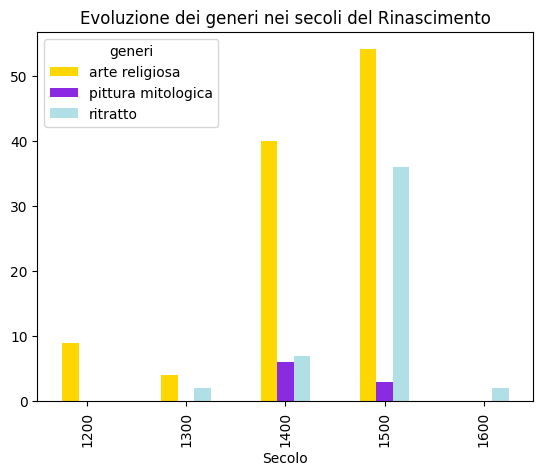

In [ ]:
df_quadri.groupby("secolo")["generi"].value_counts().unstack().plot.bar(title = "Evoluzione dei generi nei secoli del Rinascimento",
                                                                        xlabel = "Secolo",
                                                                        color = ["#FFD700", "#8A2BE2", "#B0E0E6"])

Il grafico conferma quello che era emerso in precedenza, ovvero che gli anni di maggior interesse per queste opere sono il Quattrocento e il Cinquecento, in particolare per le opere religiose e anche per i ritratti, anche se in minor quantità.

Procedo con la prossima parte dell'analisi.

Per iniziare, vado a verificare il contenuto della colonna 'contenuti', in quanto sarà essenziale per poter estrapolare i quadri che raffigurano soggetti femminili.

In [ ]:
df_quadri["contenuti"].head(10)

,contenuti
130,Maria; donna; ragazzo; Bambino Gesù
93,Gesù; uomo
67,Gesù; uomo
118,Maria; donna; ragazzo; madre; Bambino Gesù
141,Paolo di Tarso
138,Pietro
124,NaN
70,NaN
117,Maria; donna; ragazzo; madre; Bambino Gesù
56,Madonna col Bambino


Anche in questo caso abbiamo stringhe con i contenuti separati da `; ` con la presenza di valori NaN.

Vado a rimuoverli con `.dropna()`.

In [ ]:
df_quadri = df_quadri.dropna(subset=["contenuti"])

In [ ]:
df_quadri["contenuti"].head(10)

,contenuti
130,Maria; donna; ragazzo; Bambino Gesù
93,Gesù; uomo
67,Gesù; uomo
118,Maria; donna; ragazzo; madre; Bambino Gesù
141,Paolo di Tarso
138,Pietro
117,Maria; donna; ragazzo; madre; Bambino Gesù
56,Madonna col Bambino
168,uomo; Ordine francescano; monaco
148,papa Bonifacio VIII


Proseguo con le stesse operazioni fatte per le colonne precedenti:

* Rendo i valori minuscoli con `.lower()`
* Trasformo i singoli valori in liste con `.split()`
* Separo su più righe con `.explode()`

In [ ]:
df_quadri["contenuti"] = df_quadri["contenuti"].str.lower()

/tmp/ipykernel_2305/2271953502.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_quadri["contenuti"] = df_quadri["contenuti"].str.lower()


In [ ]:
df_quadri["contenuti"] = df_quadri["contenuti"].str.split("; ")

/tmp/ipykernel_2305/34641776.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_quadri["contenuti"] = df_quadri["contenuti"].str.split("; ")


In [ ]:
df_quadri = df_quadri.explode("contenuti")

In [ ]:
df_quadri

,id,titolo,artisti,data_creazione,generi,contenuti,movimenti,secolo
130,http://www.wikidata.org/entity/Q3276168,Madonna di Borgo San Lorenzo,Giotto (maschio),1290,arte religiosa,maria,protorinascimento,1200
130,http://www.wikidata.org/entity/Q3276168,Madonna di Borgo San Lorenzo,Giotto (maschio),1290,arte religiosa,donna,protorinascimento,1200
130,http://www.wikidata.org/entity/Q3276168,Madonna di Borgo San Lorenzo,Giotto (maschio),1290,arte religiosa,ragazzo,protorinascimento,1200
130,http://www.wikidata.org/entity/Q3276168,Madonna di Borgo San Lorenzo,Giotto (maschio),1290,arte religiosa,bambino gesù,protorinascimento,1200
93,http://www.wikidata.org/entity/Q3044873,Deposizione dalla croce,Giotto (maschio),1291,arte religiosa,gesù,protorinascimento,1200
...,...,...,...,...,...,...,...,...
719,http://www.wikidata.org/entity/Q112798481,Ritratto di papa Clemente VIII Aldobrandini,Cavalier d'Arpino (maschio),1598,ritratto,scrivania,manierismo; pittura rinascimentale italiana,1500
719,http://www.wikidata.org/entity/Q112798481,Ritratto di papa Clemente VIII Aldobrandini,Cavalier d'Arpino (maschio),1598,ritratto,scrittura,manierismo; pittura rinascimentale italiana,1500
928,http://www.wikidata.org/entity/Q117797593,Autoritratto di Albrecht Dürer,NaN,1600,ritratto,albrecht dürer,rinascimento tedesco,1600
2443,http://www.wikidata.org/entity/Q137169658,"Ritratto di fanciulla, ""Violante""",Giovanni Cariani (maschio),1600,ritratto,parapetto,pittura veneta; alto rinascimento,1600


A questo punto, prima di proseguire con l'analisi, per capire meglio la composizione del dataset, vado a rappresentare con un grafico quanti sono i quadri che contengono donne.

Utilizzo quindi `.contains()` per dividere i quadri in base al contenuto, `.value_counts()` per contare quanti sono e `.plot.pie()` per disegnare il grafico.

Questo mi permette di identificare quanto sarà estesa la mole di dati che userò per le analisi successive, visto che mi concentrerò solo sui contenuti che includono figure femminili.

<Axes: title={'center': 'Percentuale quadri che raffigurano soggetti femminili'}>

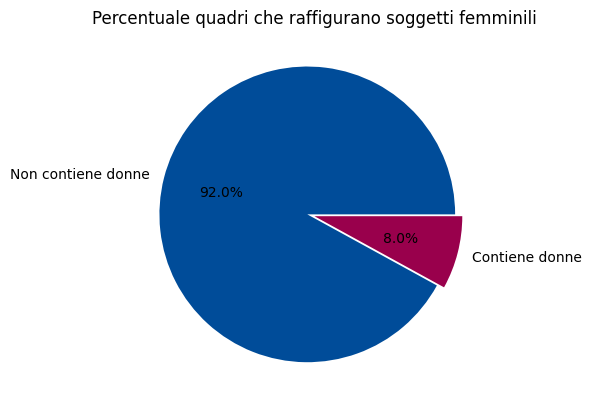

In [ ]:
df_quadri["contenuti"].str.contains("donna").value_counts().plot.pie(title  = "Percentuale quadri che raffigurano soggetti femminili",
                                                                     labels = ["Non contiene donne", "Contiene donne"],
                                                                     ylabel = "",
                                                                     autopct = "%.1f%%",
                                                                     colors = ["#004C99", "#99004C"],
                                                                     explode = [0.05, 0.0])

Nonostante la percentuale che ottengo sia bassa, il numero effettivo di opere è abbastanza da poter comunque fare una analisi:

In [ ]:
df_quadri["contenuti"].str.contains("donna").value_counts()

,count
contenuti,
False,622
True,54


Procedo quindi con l'analisi.

Vado qua a creare un nuovo DataFrame, `df_quadri_donne`, con solo i quadri che rappresentano donne.

Questo perché il passaggio potrebbe ridurre notevolmente i dati che sto trattando, e in più per avere una separazione netta con i passaggi precedenti.

In [ ]:
df_quadri_donne = df_quadri[df_quadri["contenuti"].str.contains("donna")]

In [ ]:
df_quadri_donne

,id,titolo,artisti,data_creazione,generi,contenuti,movimenti,secolo
130,http://www.wikidata.org/entity/Q3276168,Madonna di Borgo San Lorenzo,Giotto (maschio),1290,arte religiosa,donna,protorinascimento,1200
118,http://www.wikidata.org/entity/Q3276180,Madonna col Bambino ridente,Giotto (maschio),1291,arte religiosa,donna,protorinascimento,1200
117,http://www.wikidata.org/entity/Q3276171,Madonna di San Giorgio alla Costa,Giotto (maschio),1295,arte religiosa,donna,protorinascimento,1200
56,http://www.wikidata.org/entity/Q2016193,Maestà di Ognissanti,Giotto (maschio),1300,arte religiosa,madonna col bambino,gotico; protorinascimento,1300
12,http://www.wikidata.org/entity/Q734197,Visitazione,Giotto (maschio),1306,arte religiosa,donna,protorinascimento,1300
61,http://www.wikidata.org/entity/Q2066739,Pala di San Zeno,Andrea Mantegna (maschio),1457,arte religiosa,donna,rinascimento,1400
61,http://www.wikidata.org/entity/Q2066739,Pala di San Zeno,Andrea Mantegna (maschio),1457,arte religiosa,madonna col bambino,rinascimento,1400
90,http://www.wikidata.org/entity/Q2247307,Polittico della Misericordia,Piero della Francesca (maschio),1460,arte religiosa,donna,primo rinascimento,1400
90,http://www.wikidata.org/entity/Q2247307,Polittico della Misericordia,Piero della Francesca (maschio),1460,arte religiosa,madonna della misericordia,primo rinascimento,1400
9,http://www.wikidata.org/entity/Q580853,Madonna col Bambino degli Innocenti,Sandro Botticelli (maschio),1465,arte religiosa,madonna col bambino,primo rinascimento,1400


Una cosa che emerge dalla stampa dei dati è che alcuni dei quadri sono duplicati.

Questo perché in alcuni casi i contenuti hanno più valori che contengono la parola donna. Un esempio è il quadro "La pala di San Zeno":

In [ ]:
df_quadri_donne.loc[61]

,id,titolo,artisti,data_creazione,generi,contenuti,movimenti,secolo
61,http://www.wikidata.org/entity/Q2066739,Pala di San Zeno,Andrea Mantegna (maschio),1457,arte religiosa,donna,rinascimento,1400
61,http://www.wikidata.org/entity/Q2066739,Pala di San Zeno,Andrea Mantegna (maschio),1457,arte religiosa,madonna col bambino,rinascimento,1400


Vediamo che, in questo caso, abbiamo una corrispondenza sia per il valore "donna" che per "madonna".

In generale, il numero di duplicati risulta abbastanza consistente, e quasi sempre perché nel contenuto è presente "madonna". Questo è coerente anche con i risultati precedenti, dove era evidenziata l'alta quantità di opere religiose.

In [ ]:
df_quadri_donne[df_quadri_donne.duplicated(subset=["id"])]

,id,titolo,artisti,data_creazione,generi,contenuti,movimenti,secolo
61,http://www.wikidata.org/entity/Q2066739,Pala di San Zeno,Andrea Mantegna (maschio),1457,arte religiosa,madonna col bambino,rinascimento,1400
90,http://www.wikidata.org/entity/Q2247307,Polittico della Misericordia,Piero della Francesca (maschio),1460,arte religiosa,madonna della misericordia,primo rinascimento,1400
122,http://www.wikidata.org/entity/Q3210267,Madonna del Mare,Sandro Botticelli (maschio),1470,arte religiosa,madonna col bambino,primo rinascimento,1400
33,http://www.wikidata.org/entity/Q955295,Madonna di Macerata,Carlo Crivelli (maschio),1470,arte religiosa,madonna col bambino,pittura rinascimentale italiana,1400
777,http://www.wikidata.org/entity/Q115067483,Madonna del Magnificat,Sandro Botticelli (maschio),1480,arte religiosa,madonna col bambino,primo rinascimento,1400
111,http://www.wikidata.org/entity/Q2551625,Madonna del Magnificat,Sandro Botticelli (maschio),1483,arte religiosa,madonna col bambino,primo rinascimento,1400
57,http://www.wikidata.org/entity/Q2035209,Madonna del Granduca,Raffaello Sanzio (maschio),1506,arte religiosa,abito da donna,alto rinascimento,1500


Un altro aspetto interessante deriva dal quadro "Madonna del Gianluca":

In [ ]:
df_quadri_donne.loc[57]

,id,titolo,artisti,data_creazione,generi,contenuti,movimenti,secolo
57,http://www.wikidata.org/entity/Q2035209,Madonna del Granduca,Raffaello Sanzio (maschio),1506,arte religiosa,madonna col bambino,alto rinascimento,1500
57,http://www.wikidata.org/entity/Q2035209,Madonna del Granduca,Raffaello Sanzio (maschio),1506,arte religiosa,abito da donna,alto rinascimento,1500


In questo caso, abbiamo una corrispondenza con un valore errato, ovvero "abito da donna".

Normalmente dovremmo gestire questo caso separatamente ma, considerando che il quadro ha anche un contenuto effettivamente valido, ovvero "madonna col bambino", durante l'eliminazione dei duplicati la riga errata verrà già rimossa.

Vado, a questo punto, a rimuovere i duplicati, utilizzo il metodo `.drop_duplicates(subset = [])`.

In [ ]:
df_quadri_donne = df_quadri_donne.drop_duplicates(subset=["id"])

Ora che i dati sono corretti, posso andare a rappresentarli con un grafico a torta.

In questo modo, posso verificare la concentrazione dei soggetti femminili nei generi che stiamo trattando.

<Axes: title={'center': 'Distinzione nei generi dei soggetti femminili nel Rinascimento'}>

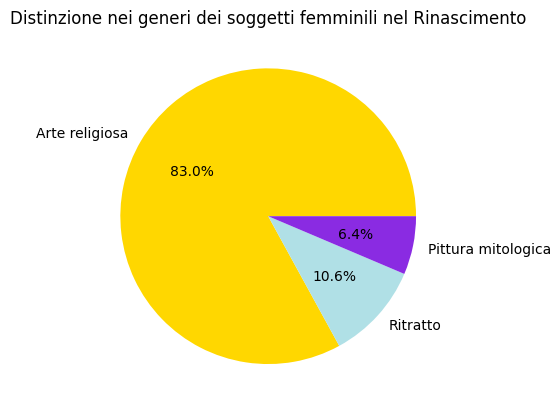

In [ ]:
df_quadri_donne["generi"].value_counts().plot.pie(title   = "Distinzione nei generi dei soggetti femminili nel Rinascimento",
                                                  labels  = ["Arte religiosa", "Ritratto", "Pittura mitologica"],
                                                  colors  = ["#FFD700",        "#B0E0E6",  "#8A2BE2"],
                                                  autopct = "%.1f%%",
                                                  ylabel  = "")

Infine, termino l'analisi andando a rappresentare i dati raggruppati per secolo.

Utilizzo gli stessi metodi usati in precedenza:

* `.groupby()` per raggruppare per secolo le righe
* `.value_counts()` per contare le righe in ogni secolo
* `.unstack().plot.bar()` per disegnare il grafico raggruppando le barre dei tre generi per secolo


<Axes: title={'center': 'Evoluzione dei generi con soggetti femminili nei secoli'}, xlabel='Secolo'>

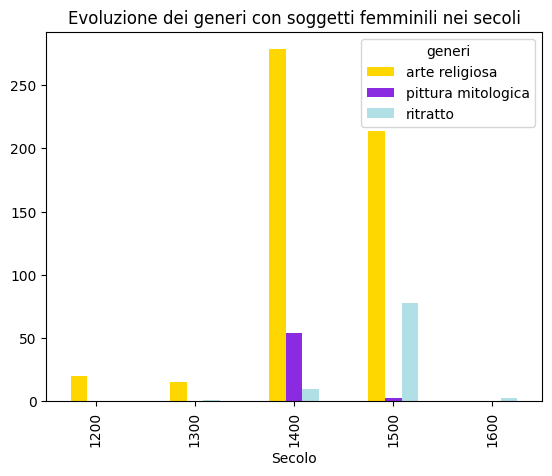

In [ ]:
df_quadri.groupby("secolo")["generi"].value_counts().unstack().plot.bar(title = "Evoluzione dei generi con soggetti femminili nei secoli",
                                                                        xlabel = "Secolo",
                                                                        color = ["#FFD700", "#8A2BE2", "#B0E0E6"])

Infine, c'è un ultimo aspetto interessante che possiamo notare sugli artisti di questi quadri.

Per vederlo, vado a fare la divisione degli autori come ho fatto per gli altri campi:

In [ ]:
df_artisti = df_quadri_donne["artisti"].str.split("; ")

In [ ]:
df_artisti = df_artisti.explode()

In [ ]:
df_artisti.value_counts()

,count
artisti,
Sandro Botticelli (maschio),16
Giotto (maschio),5
Giovanni Bellini (maschio),5
Perugino (maschio),3
Raffaello Sanzio (maschio),3
Andrea Mantegna (maschio),1
Piero della Francesca (maschio),1
Carlo Crivelli (maschio),1
Luca Signorelli (maschio),1


Due cose saltano immediatamente all'occhio:

1. Tutti gli artisti sono maschi
2. La maggior parte dei quadri sono dello stesso artista

Ovvero, Sandro Botticelli ha raffigurato un numero nettamente maggiore di figure femminili rispetto a tutti gli altri artisti di quel periodo.

Per avere una visione migliore di questo riscontro, vado a rappresentarla in un grafico.

Per rendere il tutto più leggibile, vado a rimuovere il genere dell'artista, in quanto sono tutti maschi (quindi considerato irrilevante).

In [ ]:
df_artisti = df_artisti.str.replace("(maschio)", "")

<Axes: title={'center': 'Numero di quadri per artista'}, xlabel='Numero quadri', ylabel='artisti'>

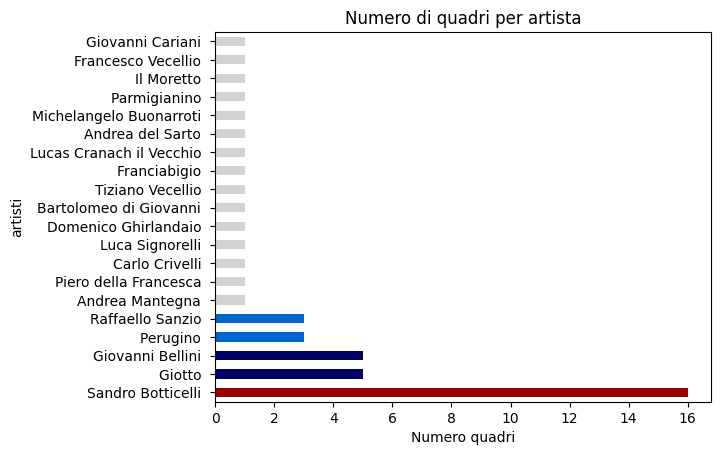

In [ ]:
df_artisti.value_counts().plot.barh(title = "Numero di quadri per artista",
                                   xlabel = "Numero quadri",
                                   color = ["#990000", "#000066", "#000066", "#0066CC", "#0066CC",
                                            "lightgray", "lightgray", "lightgray", "lightgray", "lightgray",
                                            "lightgray", "lightgray", "lightgray", "lightgray", "lightgray",
                                            "lightgray", "lightgray", "lightgray", "lightgray", "lightgray"])

## 4. Conclusione

Per concludere questa analisi, possiamo notare come, durante l'era dell'arte rinascimentale, ci sia stata una grande concentrazione di opere d'arte in particolare legate al genere del divino senza limite sui soggetti o i contenuti precisi.

Per questo progetto ho voluto prendere in analisi un particolare sottoinsieme di tutte le opere, ovvero quello con soggetti femminili che si poteva vedere maggiormente presente nei quadri di genere religioso.

Infatti è interessante notare come gli artisti tendessero a focalizzarsi su un tipo di contenuto particolare per le loro opere. In questo caso, la maggior parte degli artisti che avevano un proprio genere di soggetti o contenuti maggiormente rappresentato nelle proprie opere erano uomini.

Purtroppo però, la limitata quantità di dati forniti dal dataset rende l'analisi parziale, anche se ci permette in ogni caso di poter trarre delle prime conclusioni su come il Rinascimento abbia influenzato molto le opere e gli artisti di quel periodo.